<a href="https://colab.research.google.com/github/MadhurimaPaul-87/BCA_ML_MAKAUT_7th_Sem/blob/main/BCA_Module_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression

In [2]:
# ---------------------------------------------------------
# 1. Load Dataset
# ---------------------------------------------------------

data = fetch_california_housing(as_frame=True)

df = data.frame

print("First 5 records:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)


First 5 records:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Dataset Shape:
(20640, 9)


In [3]:
# ---------------------------------------------------------
# 2. Data Cleaning
# ---------------------------------------------------------

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Remove duplicate rows if any
df = df.drop_duplicates()

print("\nShape after removing duplicates:")
print(df.shape)



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Missing Values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Duplicate Rows:
0

Shape after removing duplicates:
(20640, 9)


In [4]:
# ---------------------------------------------------------
# 3. Handling Missing Values
# ---------------------------------------------------------

# Check whether the real dataset contains missing values
if df.isnull().sum().sum() > 0:

    # Fill missing numerical values using median
    df = df.fillna(df.median(numeric_only=True))

    print("\nMissing values handled using median.")

else:
    print("\nNo missing values are present in the dataset.")
    print("Therefore, no artificial missing values were created or modified.")



No missing values are present in the dataset.
Therefore, no artificial missing values were created or modified.


In [5]:
# ---------------------------------------------------------
# 4. Separate Features and Target
# ---------------------------------------------------------

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

print("\nFeatures:")
print(X.columns)

print("\nTarget:")
print(y.name)



Features:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

Target:
MedHouseVal


In [6]:
# ---------------------------------------------------------
# 5. Feature Selection
# ---------------------------------------------------------

# Select the 5 most important features using F-test
selector = SelectKBest(score_func=f_regression, k=5)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("\nSelected Features:")
print(selected_features.tolist())



Selected Features:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Latitude']


In [7]:
# ---------------------------------------------------------
# 6. Train-Test Split
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])



Training samples: 16512
Testing samples: 4128


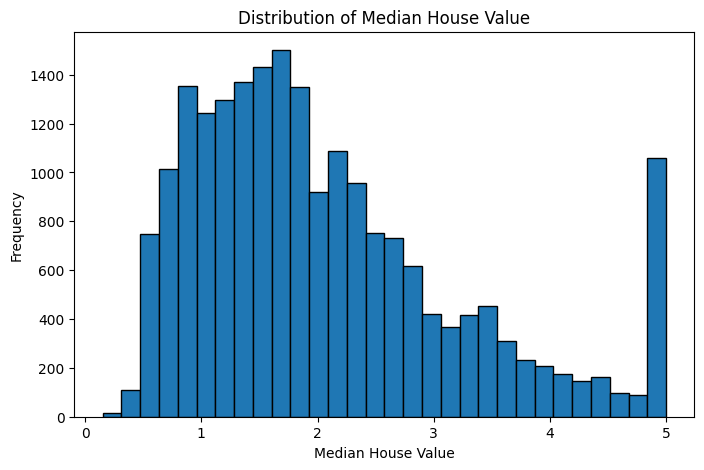

In [8]:
# ---------------------------------------------------------
# 7. Visualization using Matplotlib
# ---------------------------------------------------------

# Distribution of target variable
plt.figure(figsize=(8, 5))

plt.hist(y, bins=30, edgecolor="black")

plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.title("Distribution of Median House Value")

plt.show()

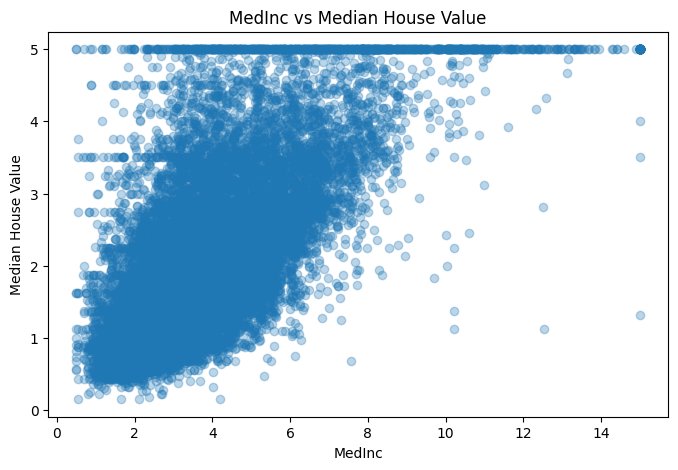

In [9]:
# ---------------------------------------------------------
# 8. Feature vs Target Visualization
# ---------------------------------------------------------

# Plot the first selected feature against target
plt.figure(figsize=(8, 5))

plt.scatter(X.iloc[:, 0], y, alpha=0.3)

plt.xlabel(X.columns[0])
plt.ylabel("Median House Value")
plt.title(
    X.columns[0] + " vs Median House Value"
)

plt.show()